�� Loading data...
✅ Data loaded! Shape: (9968, 32)
✅ Stock_Price: 5 columns
✅ Sentiment: 3 columns
✅ Twitter_Engagement: 5 columns
✅ Rolling_Averages: 4 columns

�� Creating Stock_Price heatmap...
✅ Saved: C:\Users\PC\OneDrive\Documents\DS project\results\stock_price_correlation.png


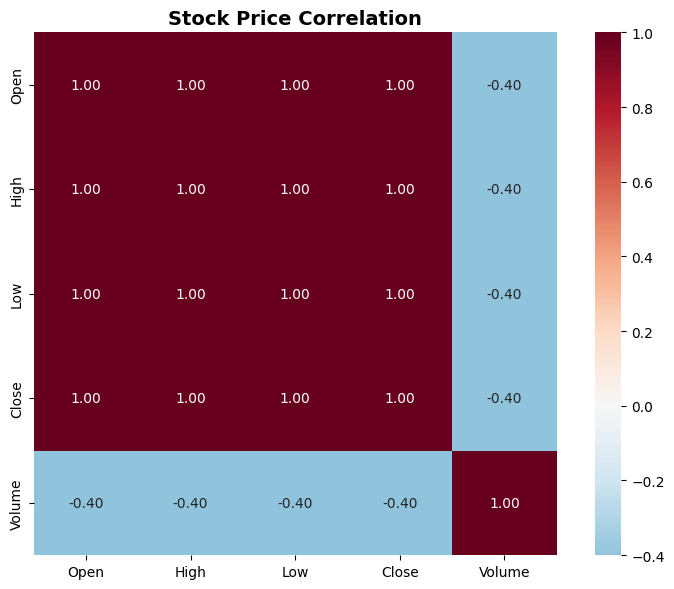


�� Creating Sentiment heatmap...
✅ Saved: C:\Users\PC\OneDrive\Documents\DS project\results\sentiment_correlation.png


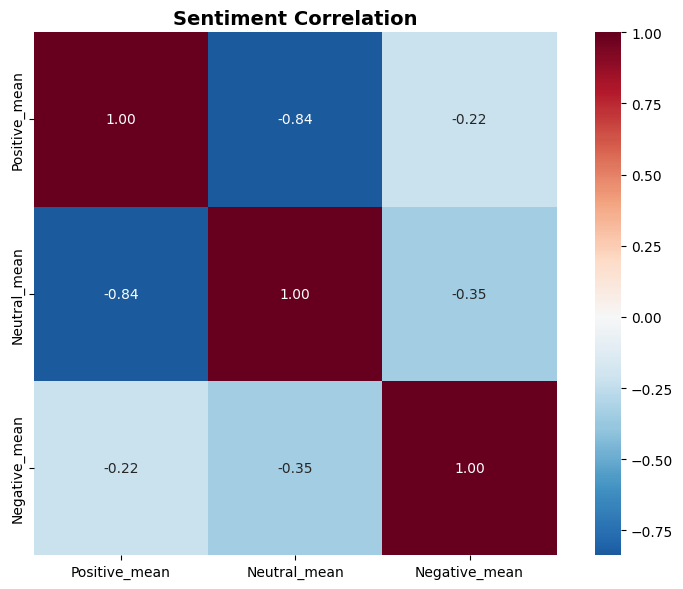


�� Creating Twitter_Engagement heatmap...
✅ Saved: C:\Users\PC\OneDrive\Documents\DS project\results\twitter_engagement_correlation.png


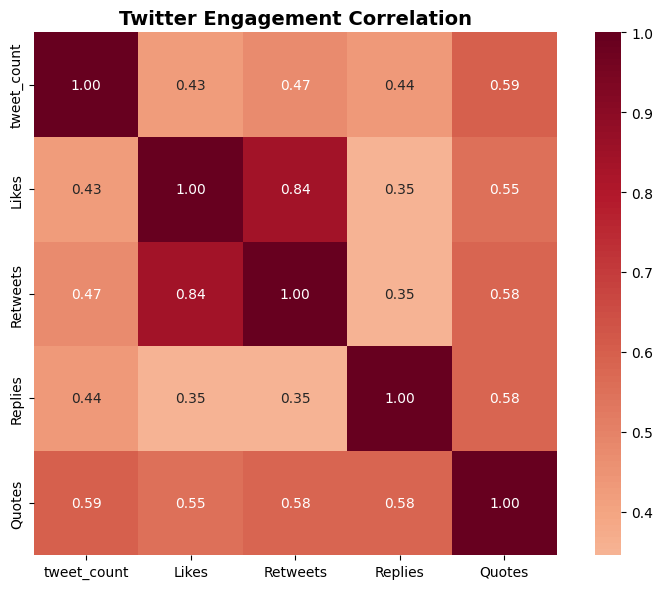


�� Creating Rolling_Averages heatmap...
✅ Saved: C:\Users\PC\OneDrive\Documents\DS project\results\rolling_averages_correlation.png


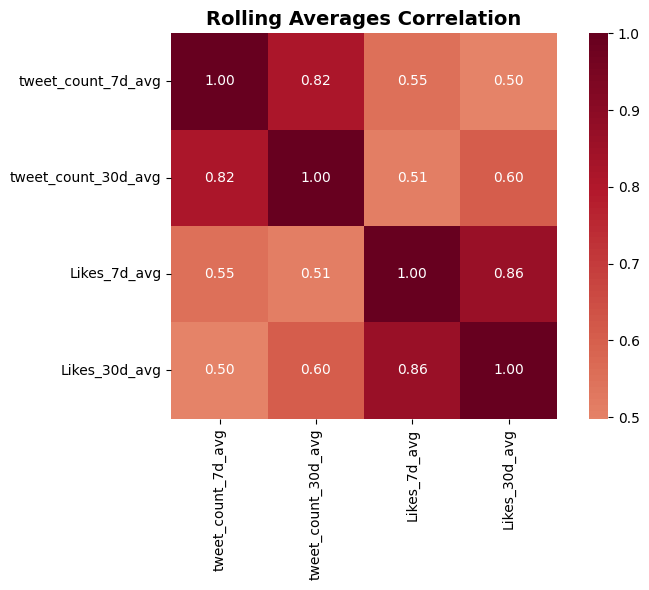


🔍 Creating key comparison heatmap...
✅ Saved: C:\Users\PC\OneDrive\Documents\DS project\results\key_features_comparison.png


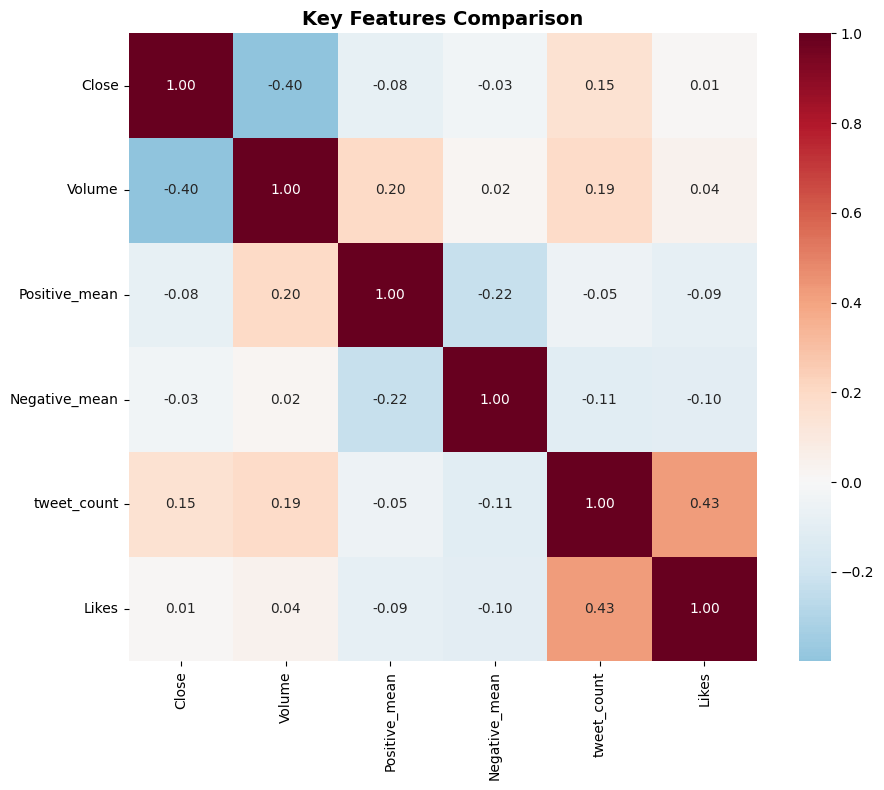


📊 Key Insights:
   - Close vs Positive_mean: -0.078
   - Close vs tweet_count: 0.151
   - Volume vs Likes: 0.043


In [4]:
# ================================================================
# SIMPLE CATEGORY-BASED CORRELATION HEATMAPS
# ================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set up paths
project_root = r"C:\Users\PC\OneDrive\Documents\DS project"
processed_data_dir = os.path.join(project_root, "processed_data")
results_dir = os.path.join(project_root, "results")
os.makedirs(results_dir, exist_ok=True)

# Load data
print("�� Loading data...")
data_path = os.path.join(processed_data_dir, "final_cleaned_data.csv")
df = pd.read_csv(data_path)
print(f"✅ Data loaded! Shape: {df.shape}")

# Define categories
categories = {
    'Stock_Price': ['Open', 'High', 'Low', 'Close', 'Volume'],
    'Sentiment': ['Positive_mean', 'Neutral_mean', 'Negative_mean'],
    'Twitter_Engagement': ['tweet_count', 'Likes', 'Retweets', 'Replies', 'Quotes'],
    'Rolling_Averages': ['tweet_count_7d_avg', 'tweet_count_30d_avg', 'Likes_7d_avg', 'Likes_30d_avg']
}

# Filter available columns for each category
available_categories = {}
for cat_name, cat_cols in categories.items():
    available_cols = [col for col in cat_cols if col in df.columns]
    if available_cols:
        available_categories[cat_name] = available_cols
        print(f"✅ {cat_name}: {len(available_cols)} columns")

# Create individual heatmaps for each category
for cat_name, cat_cols in available_categories.items():
    print(f"\n�� Creating {cat_name} heatmap...")
    
    # Get correlation data for this category
    cat_data = df[cat_cols].corr()
    
    # Create heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cat_data,
        annot=True,
        cmap='RdBu_r',
        center=0,
        square=True,
        fmt='.2f'
    )
    
    plt.title(f'{cat_name.replace("_", " ").title()} Correlation', fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    # Save plot
    plot_path = os.path.join(results_dir, f"{cat_name.lower()}_correlation.png")
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    print(f"✅ Saved: {plot_path}")
    
    plt.show()

# Now create a simple comparison heatmap with key features only
print(f"\n🔍 Creating key comparison heatmap...")

# Select only the most important features for comparison
key_features = ['Close', 'Volume', 'Positive_mean', 'Negative_mean', 'tweet_count', 'Likes']
key_features = [col for col in key_features if col in df.columns]

if len(key_features) >= 2:
    comparison_data = df[key_features].corr()
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        comparison_data,
        annot=True,
        cmap='RdBu_r',
        center=0,
        square=True,
        fmt='.2f'
    )
    
    plt.title('Key Features Comparison', fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    # Save comparison plot
    comp_path = os.path.join(results_dir, "key_features_comparison.png")
    plt.savefig(comp_path, dpi=300, bbox_inches='tight')
    print(f"✅ Saved: {comp_path}")
    
    plt.show()
    
    # Show key insights
    print(f"\n📊 Key Insights:")
    print(f"   - Close vs Positive_mean: {comparison_data.loc['Close', 'Positive_mean']:.3f}")
    print(f"   - Close vs tweet_count: {comparison_data.loc['Close', 'tweet_count']:.3f}")
    print(f"   - Volume vs Likes: {comparison_data.loc['Volume', 'Likes']:.3f}")
else:
    print("⚠️ Not enough key features found for comparison")

�� Creating sentiment vs price graphs for each stock...
✅ Found 8 stocks: ['ADANIENT' 'BHARTIARTL' 'HCLTECH' 'HDFCBANK' 'ICICIBANK' 'INFY' 'SBIN'
 'TATASTEEL']
✅ Sentiment vs price graphs saved to: C:\Users\PC\OneDrive\Documents\DS project\results\sentiment_vs_price_by_stock.png


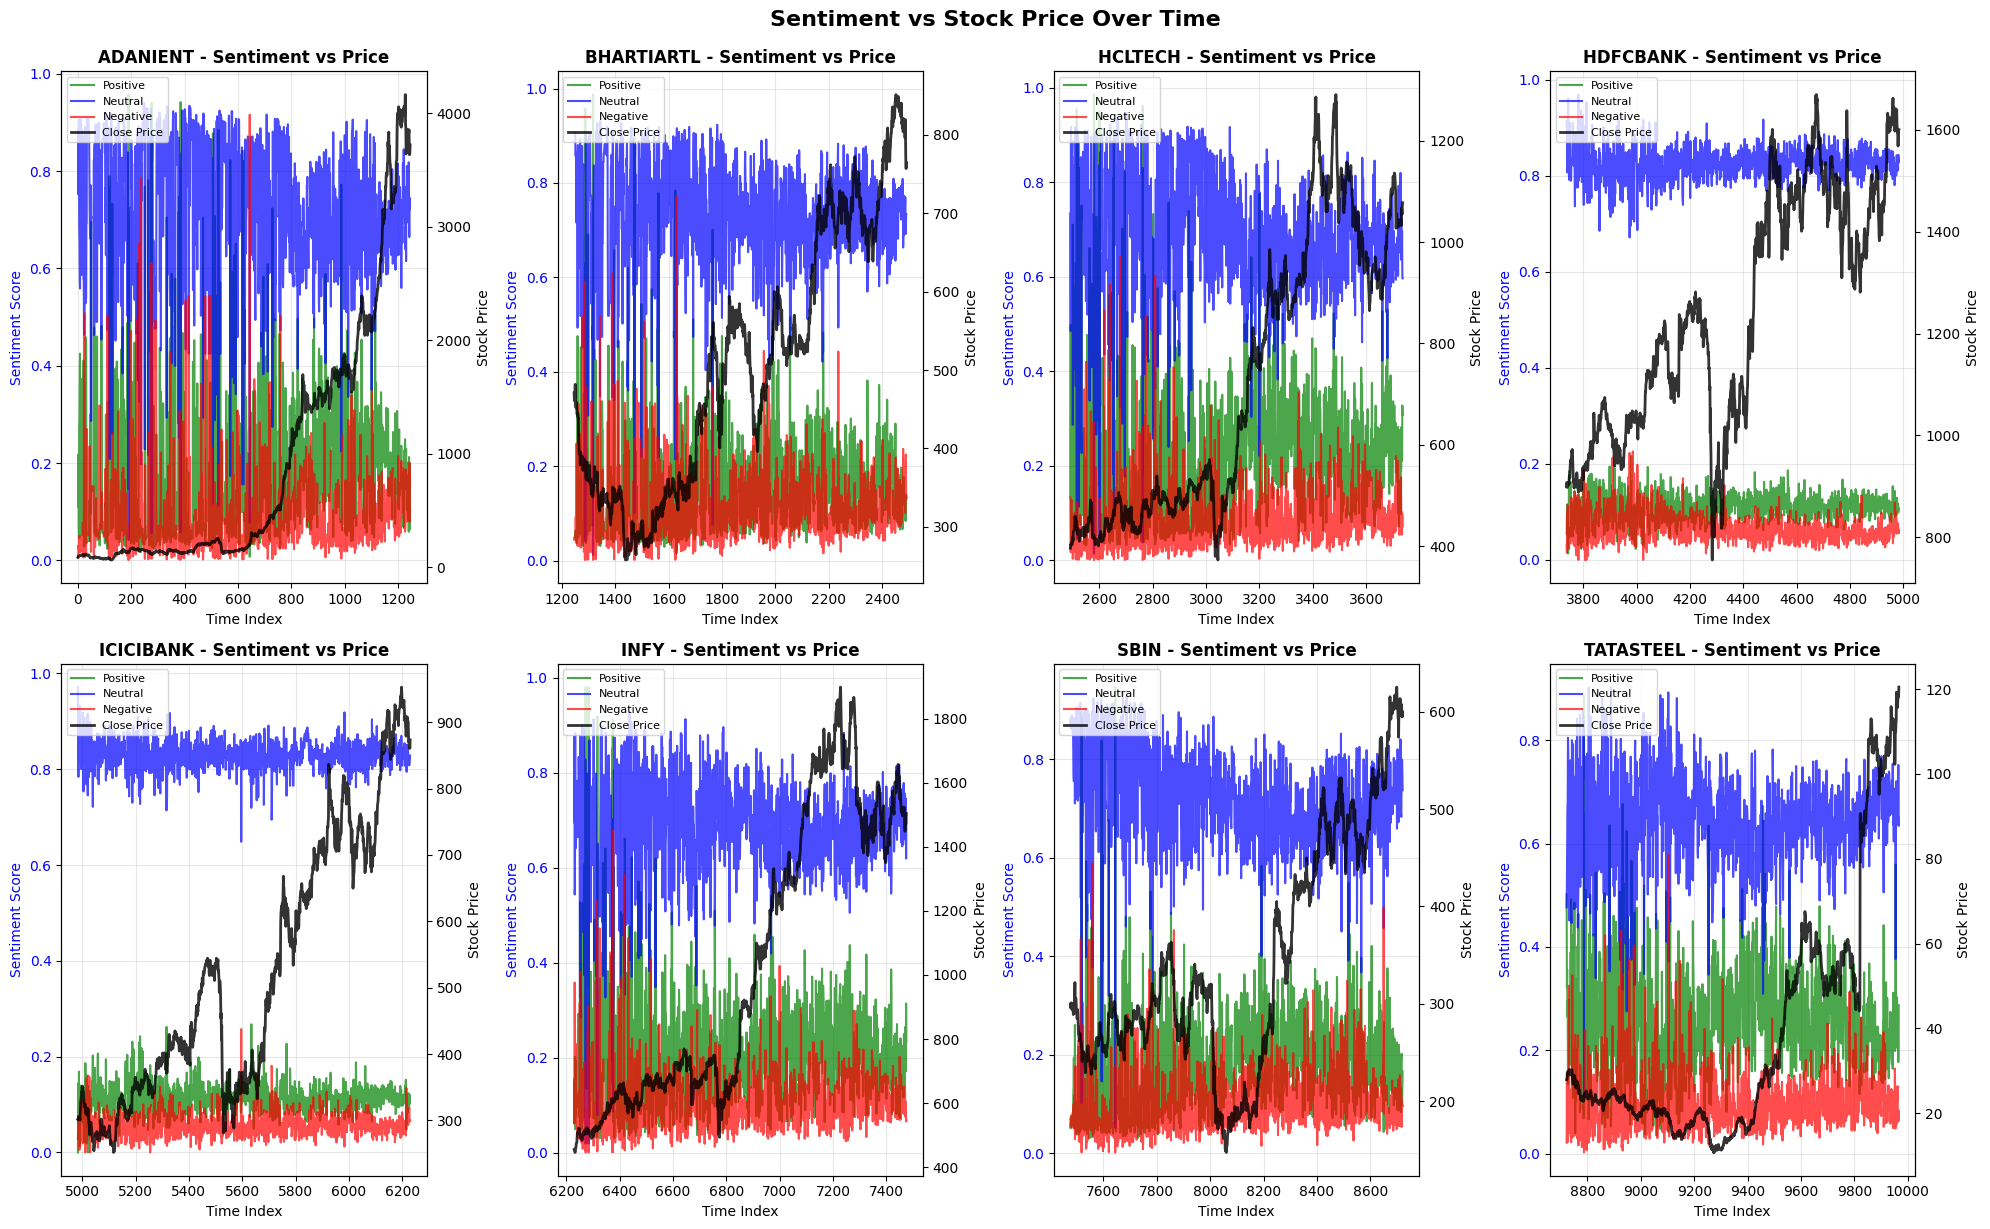


📈 Creating sentiment-price scatter plots...
✅ Scatter plots saved to: C:\Users\PC\OneDrive\Documents\DS project\results\sentiment_price_scatter_by_stock.png


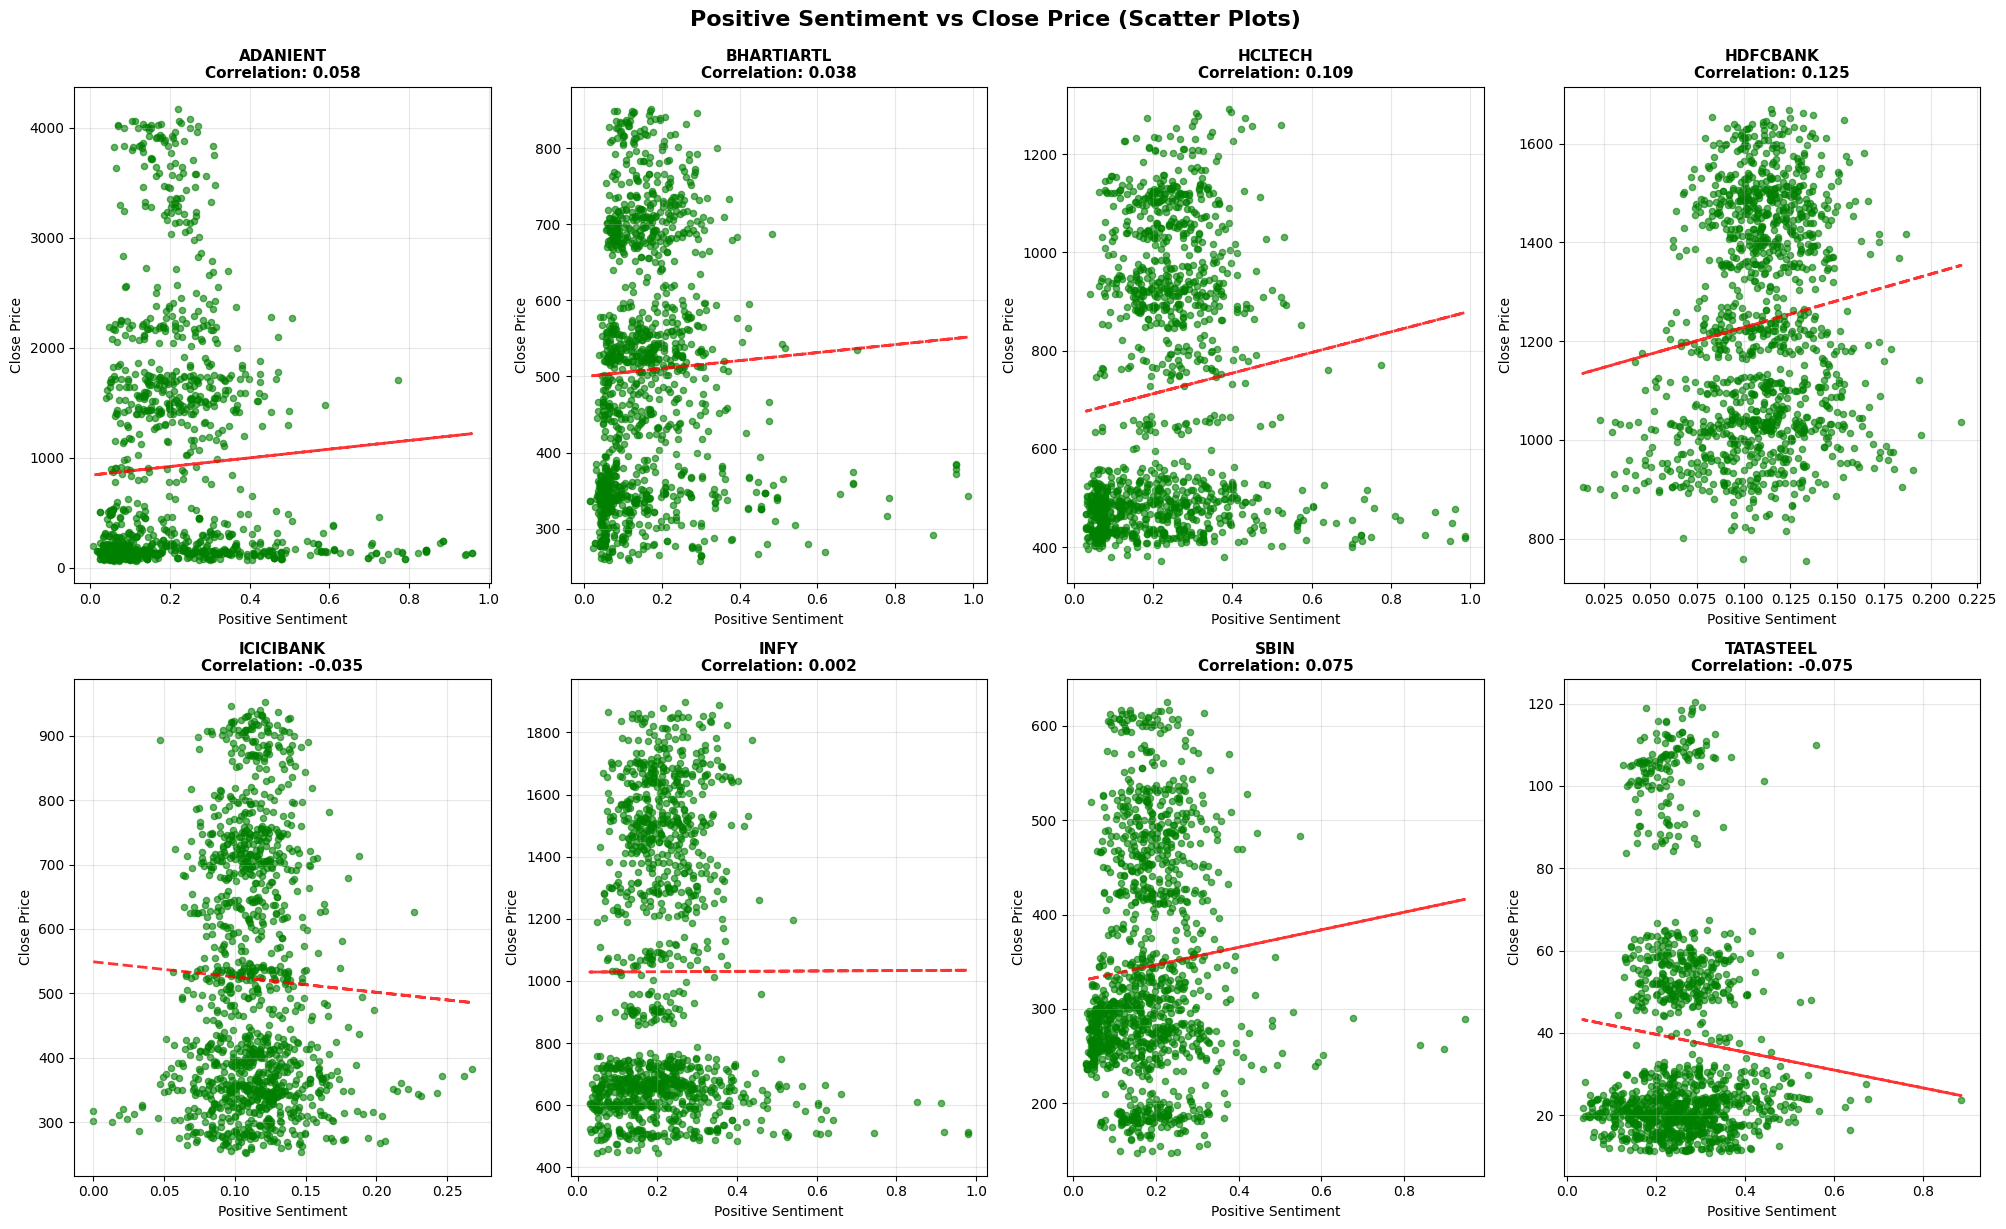

✅ Scatter plots saved to: C:\Users\PC\OneDrive\Documents\DS project\results\sentiment_price_scatter_by_stock.png


<Figure size 640x480 with 0 Axes>


📊 Sentiment-Price Correlations by Stock:
ADANIENT     | Positive Sentiment vs Price:  0.058
BHARTIARTL   | Positive Sentiment vs Price:  0.038
HCLTECH      | Positive Sentiment vs Price:  0.109
HDFCBANK     | Positive Sentiment vs Price:  0.125
ICICIBANK    | Positive Sentiment vs Price: -0.035
INFY         | Positive Sentiment vs Price:  0.002
SBIN         | Positive Sentiment vs Price:  0.075
TATASTEEL    | Positive Sentiment vs Price: -0.075


In [7]:
# ================================================================
# SENTIMENT VS PRICE GRAPHS FOR EACH STOCK
# ================================================================

print("�� Creating sentiment vs price graphs for each stock...")

# Get unique stocks
stocks = df['Stock'].unique()
print(f"✅ Found {len(stocks)} stocks: {stocks}")

# Create subplots for each stock
fig, axes = plt.subplots(2, 4, figsize=(20, 12))
axes = axes.flatten()  # Flatten to 1D array for easier indexing

# Color palette for different sentiment types
colors = ['green', 'blue', 'red']
sentiment_cols = ['Positive_mean', 'Neutral_mean', 'Negative_mean']

for i, stock in enumerate(stocks):
    if i < len(axes):  # Make sure we don't exceed subplot count
        ax = axes[i]
        
        # Get data for this stock
        stock_data = df[df['Stock'] == stock].copy()
        stock_data = stock_data.sort_values('Datetime')
        
        # Create the plot
        ax2 = ax.twinx()  # Secondary y-axis for price
        
        # Plot sentiment scores
        for j, col in enumerate(sentiment_cols):
            if col in stock_data.columns:
                ax.plot(stock_data.index, stock_data[col], 
                       color=colors[j], label=col.replace('_mean', ''), 
                       alpha=0.7, linewidth=1.5)
        
        # Plot stock price on secondary y-axis
        if 'Close' in stock_data.columns:
            ax2.plot(stock_data.index, stock_data['Close'], 
                    color='black', label='Close Price', 
                    linewidth=2, alpha=0.8)
        
        # Customize the plot
        ax.set_title(f'{stock} - Sentiment vs Price', fontweight='bold', fontsize=12)
        ax.set_xlabel('Time Index')
        ax.set_ylabel('Sentiment Score', color='blue')
        ax2.set_ylabel('Stock Price', color='black')
        
        # Add legend
        lines1, labels1 = ax.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=8)
        
        # Grid
        ax.grid(True, alpha=0.3)
        
        # Color the y-axis labels
        ax.tick_params(axis='y', labelcolor='blue')
        ax2.tick_params(axis='y', labelcolor='black')

# Remove empty subplots
for i in range(len(stocks), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.suptitle('Sentiment vs Stock Price Over Time', fontsize=16, fontweight='bold', y=1.02)

# Save the plot
sentiment_price_path = os.path.join(results_dir, "sentiment_vs_price_by_stock.png")
plt.savefig(sentiment_price_path, dpi=300, bbox_inches='tight')
print(f"✅ Sentiment vs price graphs saved to: {sentiment_price_path}")

plt.show()

print(f"\n📈 Creating sentiment-price scatter plots...")

fig2, axes2 = plt.subplots(2, 4, figsize=(20, 12))
axes2 = axes2.flatten()

for i, stock in enumerate(stocks):
    if i < len(axes2):
        ax = axes2[i]

        # Get data
        stock_data = df[df['Stock'] == stock].copy()

        if 'Positive_mean' in stock_data.columns and 'Close' in stock_data.columns:
            x = stock_data['Positive_mean'].values
            y = stock_data['Close'].values

            # Remove NaN / Inf
            mask = np.isfinite(x) & np.isfinite(y)
            x = x[mask]
            y = y[mask]

            if len(x) > 1 and np.std(x) > 0:  # Only plot if data is valid
                ax.scatter(x, y, alpha=0.6, s=20, color='green')

                # Fit trend line
                z = np.polyfit(x, y, 1)
                p = np.poly1d(z)
                ax.plot(x, p(x), "r--", alpha=0.8, linewidth=2)

                # Correlation
                corr = np.corrcoef(x, y)[0, 1]
                ax.set_title(f'{stock}\nCorrelation: {corr:.3f}', fontweight='bold', fontsize=11)
            else:
                ax.text(0.5, 0.5, "No valid data", ha='center', va='center',
                        transform=ax.transAxes, fontsize=10, color='red')

            ax.set_xlabel('Positive Sentiment')
            ax.set_ylabel('Close Price')
            ax.grid(True, alpha=0.3)

# Remove empty subplots
for i in range(len(stocks), len(axes2)):
    fig2.delaxes(axes2[i])

plt.tight_layout()
plt.suptitle('Positive Sentiment vs Close Price (Scatter Plots)',
             fontsize=16, fontweight='bold', y=1.02)

# Save
scatter_path = os.path.join(results_dir, "sentiment_price_scatter_by_stock.png")
plt.savefig(scatter_path, dpi=300, bbox_inches='tight')
print(f"✅ Scatter plots saved to: {scatter_path}")

plt.show()


# Remove empty subplots
for i in range(len(stocks), len(axes2)):
    fig2.delaxes(axes2[i])

plt.tight_layout()
plt.suptitle('Positive Sentiment vs Close Price (Scatter Plots)', fontsize=16, fontweight='bold', y=1.02)

# Save the scatter plot
scatter_path = os.path.join(results_dir, "sentiment_price_scatter_by_stock.png")
plt.savefig(scatter_path, dpi=300, bbox_inches='tight')
print(f"✅ Scatter plots saved to: {scatter_path}")

plt.show()

# Summary of correlations
print(f"\n📊 Sentiment-Price Correlations by Stock:")
print("="*50)
for stock in stocks:
    stock_data = df[df['Stock'] == stock]
    if 'Positive_mean' in stock_data.columns and 'Close' in stock_data.columns:
        corr = stock_data['Positive_mean'].corr(stock_data['Close'])
        print(f"{stock:12} | Positive Sentiment vs Price: {corr:6.3f}")